# Alberta Electricity Market Live Dashboard
### Live data pipeline: AESO API &rarr; Python (Jupyter) &rarr; SQL &rarr; Power BI

**What this notebook does**
1. Pulls **live/near-real-time** electricity pool price and demand (load) data for Alberta directly from the AESO (Alberta Electric System Operator) public API
2. Cleans and merges the price + load data into one table
3. Flags abnormal price spikes using rolling statistics (anomaly detection)
4. Exports the results to **CSV** and a **SQLite database** so the same data can be queried in SQL and visualized in Power BI
5. Produces a few quick exploratory charts

> If you've never worked with a live API before, read `AESO_Dashboard_Explainer.pdf` alongside this notebook — it explains what's happening at each step in plain language.

**Data source:** AESO Public API — https://developer-apim.aeso.ca/ (official, free, requires a no-cost signup + subscription key)


## 1. Setup

Run this cell first. It imports everything the notebook needs.

If any package is missing, run this once in a terminal / notebook cell:
```
pip install requests pandas numpy matplotlib
```
(`sqlite3` ships with Python already — no install needed.)


In [1]:
import requests
import pandas as pd
import numpy as np
import sqlite3
import getpass
from datetime import datetime, timedelta

pd.set_option("display.max_columns", None)
print("Libraries loaded.")


Libraries loaded.


## 2. API key configuration

The AESO API requires a **free API key**. To get one:
1. Go to https://developer-apim.aeso.ca/signup and register with your email
2. Confirm your email, then sign in
3. Click **Products** (top right) &rarr; subscribe to **AESO Public API**
4. Click **Show** next to your key and copy it

**Never type your key directly into a notebook cell that you might commit to GitHub.**
The cell below uses `getpass` so the key is entered privately and is *not* saved into the
notebook file when you save it.

If you don't have a key yet (or just want to test the notebook first), leave `USE_LIVE_API`
set to `False` below — the notebook will generate realistic sample data with the exact same
structure the real API returns, so every downstream step (cleaning, SQL export, Power BI) still works.


In [2]:
# --- Toggle this once you have your API key ---
USE_LIVE_API = False   # set to True after you have an AESO API key

API_KEY = None
if USE_LIVE_API:
    API_KEY = getpass.getpass("Paste your AESO API key (input hidden): ")

# --- Date range to pull ---
# AESO's API returns actual data up to "now" and a short forecast window ahead.
# 30 days is a good starting range: enough data to see patterns, small enough to load fast.
END_DATE = datetime.today().date()
START_DATE = END_DATE - timedelta(days=30)

print(f"Live API mode: {USE_LIVE_API}")
print(f"Date range: {START_DATE} to {END_DATE}")


Live API mode: False
Date range: 2026-07-25 to 2026-08-24


## 3. Pull functions

Two small functions, one per AESO endpoint:
- `get_pool_price()` &rarr; hourly pool price ($/MWh), forecast price, and 30-day rolling average
- `get_internal_load()` &rarr; hourly Alberta Internal Load (demand, in MW) and forecast load

Both follow the same pattern: **GET request &rarr; JSON response &rarr; flatten into a DataFrame.**
This pattern is the same for almost every REST API you'll ever call — Statistics Canada,
weather services, financial data providers, all of it.


In [3]:
POOL_PRICE_URL = "https://apimgw.aeso.ca/public/poolprice-api/v1.1/price/poolPrice"
LOAD_URL = "https://apimgw.aeso.ca/public/actualforecast-api/v1/load/albertaInternalLoad"


def get_pool_price(api_key, start_date, end_date):
    '''Pull hourly pool price data from the AESO API and return a clean DataFrame.'''
    headers = {"API-KEY": api_key}
    params = {"startDate": start_date.strftime("%Y-%m-%d"),
              "endDate": end_date.strftime("%Y-%m-%d")}

    response = requests.get(POOL_PRICE_URL, headers=headers, params=params, timeout=30)
    response.raise_for_status()  # raises an error if the call failed (bad key, etc.)

    payload = response.json()
    records = payload["return"]["Pool Price Report"]
    df = pd.json_normalize(records)

    df = df.rename(columns={
        "begin_datetime_mpt": "time_local",
        "begin_datetime_utc": "time_utc",
        "pool_price": "pool_price",
        "forecast_pool_price": "forecast_pool_price",
        "rolling_30day_avg": "rolling_30day_avg",
    })
    df["time_local"] = pd.to_datetime(df["time_local"])
    df["time_utc"] = pd.to_datetime(df["time_utc"])
    for col in ["pool_price", "forecast_pool_price", "rolling_30day_avg"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    return df


def get_internal_load(api_key, start_date, end_date):
    '''Pull hourly Alberta Internal Load (demand) data from the AESO API.'''
    headers = {"API-KEY": api_key}
    params = {"startDate": start_date.strftime("%Y-%m-%d"),
              "endDate": end_date.strftime("%Y-%m-%d")}

    response = requests.get(LOAD_URL, headers=headers, params=params, timeout=30)
    response.raise_for_status()

    payload = response.json()
    records = payload["return"]["Actual Forecast Report"]
    df = pd.json_normalize(records)

    df = df.rename(columns={
        "begin_datetime_mpt": "time_local",
        "begin_datetime_utc": "time_utc",
        "alberta_internal_load": "demand_mw",
        "forecast_alberta_internal_load": "forecast_demand_mw",
    })
    df["time_local"] = pd.to_datetime(df["time_local"])
    df["time_utc"] = pd.to_datetime(df["time_utc"])
    for col in ["demand_mw", "forecast_demand_mw"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    return df

print("Pull functions ready.")


Pull functions ready.


## 4. Sample-data generator (used only when `USE_LIVE_API = False`)

This creates data with the **exact same columns and shape** as the real API response,
so the rest of the notebook doesn't need to change once you switch to live data.
It's clearly labeled so you never mistake it for the real thing.


In [4]:
def generate_sample_data(start_date, end_date, seed=42):
    '''Simulate AESO-style price + load data for testing without an API key.'''
    rng = np.random.default_rng(seed)
    hours = pd.date_range(start=start_date, end=end_date, freq="h", inclusive="left")
    n = len(hours)

    # base daily demand curve (higher in morning/evening, lower overnight)
    hour_of_day = hours.hour
    daily_shape = 9500 + 1800 * np.sin((hour_of_day - 7) / 24 * 2 * np.pi) + 600 * np.sin((hour_of_day - 18) / 12 * np.pi)
    demand = daily_shape + rng.normal(0, 150, n)

    # price loosely follows demand with random spikes (mimics real Alberta market behaviour)
    base_price = 20 + (demand - demand.min()) / (demand.max() - demand.min()) * 60
    spikes = rng.choice([0, 1], size=n, p=[0.97, 0.03]) * rng.uniform(80, 400, n)
    price = np.clip(base_price + rng.normal(0, 8, n) + spikes, 0, 1000)

    df_price = pd.DataFrame({
        "time_local": hours,
        "time_utc": hours + pd.Timedelta(hours=6),
        "pool_price": price.round(2),
        "forecast_pool_price": (price + rng.normal(0, 5, n)).round(2),
        "rolling_30day_avg": pd.Series(price).rolling(24 * 30, min_periods=1).mean().round(2),
        "data_source": "SIMULATED",
    })

    df_load = pd.DataFrame({
        "time_local": hours,
        "time_utc": hours + pd.Timedelta(hours=6),
        "demand_mw": demand.round(0),
        "forecast_demand_mw": (demand + rng.normal(0, 100, n)).round(0),
        "data_source": "SIMULATED",
    })

    return df_price, df_load

print("Sample-data generator ready.")


Sample-data generator ready.


## 5. Run the pull

This is the cell that actually fetches (or simulates) the data. Re-running this cell
is what makes it "live" — every time you run it, you get whatever the current data looks like.


In [5]:
if USE_LIVE_API:
    df_price = get_pool_price(API_KEY, START_DATE, END_DATE)
    df_load = get_internal_load(API_KEY, START_DATE, END_DATE)
    df_price["data_source"] = "LIVE"
    df_load["data_source"] = "LIVE"
    print(f"Pulled {len(df_price)} live price rows and {len(df_load)} live load rows from AESO.")
else:
    df_price, df_load = generate_sample_data(START_DATE, END_DATE)
    print(f"Generated {len(df_price)} SIMULATED price rows and {len(df_load)} SIMULATED load rows.")
    print("Set USE_LIVE_API = True with a real key in Section 2 to pull actual AESO data.")

df_price.head()


Generated 720 SIMULATED price rows and 720 SIMULATED load rows.
Set USE_LIVE_API = True with a real key in Section 2 to pull actual AESO data.


,time_local,time_utc,pool_price,forecast_pool_price,rolling_30day_avg,data_source
0,2026-07-25 00:00:00,2026-07-25 06:00:00,51.23,47.31,51.23,SIMULATED
1,2026-07-25 01:00:00,2026-07-25 07:00:00,27.20,42.50,39.21,SIMULATED
2,2026-07-25 02:00:00,2026-07-25 08:00:00,23.57,18.14,34.00,SIMULATED
3,2026-07-25 03:00:00,2026-07-25 09:00:00,25.98,19.70,32.00,SIMULATED
4,2026-07-25 04:00:00,2026-07-25 10:00:00,18.68,21.23,29.33,SIMULATED


## 6. Merge and clean

Join price and load into a single hourly table, and do the basic cleaning every real
dataset needs: consistent types, no duplicate timestamps, sorted chronologically.


In [6]:
df = pd.merge(
    df_price[["time_local", "time_utc", "pool_price", "forecast_pool_price", "rolling_30day_avg", "data_source"]],
    df_load[["time_local", "demand_mw", "forecast_demand_mw"]],
    on="time_local",
    how="inner"
)

df = df.drop_duplicates(subset="time_local")
df = df.sort_values("time_local").reset_index(drop=True)

# fill isolated missing prices (rare AESO reporting gaps) using forward-fill, cap at 3 hours
df["pool_price"] = df["pool_price"].ffill(limit=3)

print(f"Merged table: {len(df)} rows, {df['time_local'].min()} to {df['time_local'].max()}")
df.info()


Merged table: 720 rows, 2026-07-25 00:00:00 to 2026-08-23 23:00:00
<class 'pandas.DataFrame'>
RangeIndex: 720 entries, 0 to 719
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   time_local           720 non-null    datetime64[s] 
 1   time_utc             720 non-null    datetime64[us]
 2   pool_price           720 non-null    float64       
 3   forecast_pool_price  720 non-null    float64       
 4   rolling_30day_avg    720 non-null    float64       
 5   data_source          720 non-null    str           
 6   demand_mw            720 non-null    float64       
 7   forecast_demand_mw   720 non-null    float64       
dtypes: datetime64[s](1), datetime64[us](1), float64(5), str(1)
memory usage: 45.1 KB


## 7. Anomaly detection — flag price spikes

Same technique referenced in the Financial Risk project: a rolling mean/standard deviation
z-score. Any hour where price is more than 2.5 standard deviations above its trailing
7-day average gets flagged as a spike. This is a genuinely useful signal for an energy
company (staffing, hedging, demand response decisions).


In [7]:
window = 24 * 7  # 7 days of hourly data

df["rolling_mean_7d"] = df["pool_price"].rolling(window, min_periods=24).mean()
df["rolling_std_7d"] = df["pool_price"].rolling(window, min_periods=24).std()
df["price_zscore"] = (df["pool_price"] - df["rolling_mean_7d"]) / df["rolling_std_7d"]
df["is_price_spike"] = (df["price_zscore"] > 2.5).astype(int)

spike_count = df["is_price_spike"].sum()
spike_rate = spike_count / len(df) * 100
print(f"Flagged {spike_count} price-spike hours out of {len(df)} ({spike_rate:.1f}%).")

df[df["is_price_spike"] == 1][["time_local", "pool_price", "rolling_mean_7d", "price_zscore"]].head(10)


Flagged 22 price-spike hours out of 720 (3.1%).


,time_local,pool_price,rolling_mean_7d,price_zscore
34,2026-07-26 10:00:00,411.24,57.643143,5.514074
59,2026-07-27 11:00:00,239.06,57.520500,3.260925
62,2026-07-27 14:00:00,340.02,62.523810,4.271472
87,2026-07-28 15:00:00,314.76,62.378068,4.054829
122,2026-07-30 02:00:00,415.37,60.940813,5.640250
163,2026-07-31 19:00:00,348.58,61.024390,4.831462
164,2026-07-31 20:00:00,460.23,63.443818,5.923792
230,2026-08-03 14:00:00,443.32,61.570119,6.133450
248,2026-08-04 08:00:00,337.77,62.947143,4.170011
315,2026-08-07 03:00:00,372.53,62.095952,5.007234


## 8. Quick exploratory charts

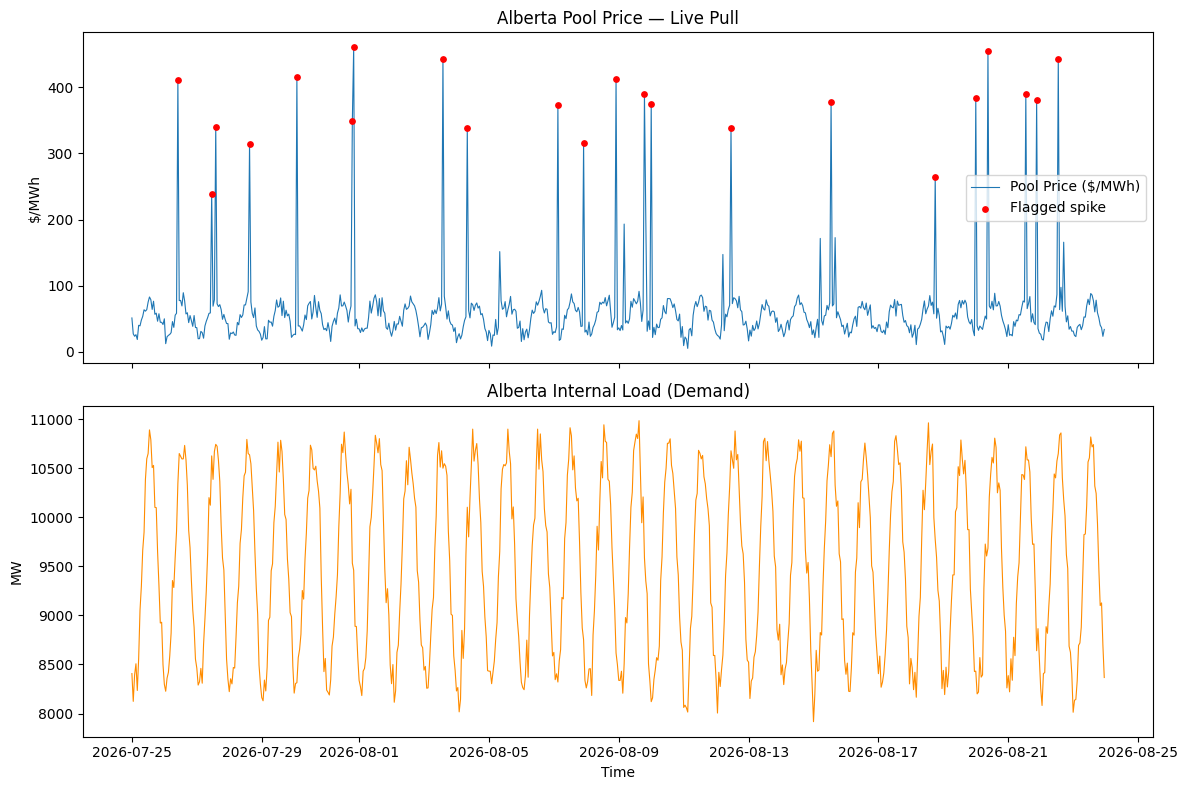

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(df["time_local"], df["pool_price"], linewidth=0.8, label="Pool Price ($/MWh)")
spikes = df[df["is_price_spike"] == 1]
axes[0].scatter(spikes["time_local"], spikes["pool_price"], color="red", s=15, label="Flagged spike", zorder=5)
axes[0].set_ylabel("$/MWh")
axes[0].set_title("Alberta Pool Price — Live Pull")
axes[0].legend()

axes[1].plot(df["time_local"], df["demand_mw"], linewidth=0.8, color="darkorange")
axes[1].set_ylabel("MW")
axes[1].set_title("Alberta Internal Load (Demand)")
axes[1].set_xlabel("Time")

plt.tight_layout()
plt.show()


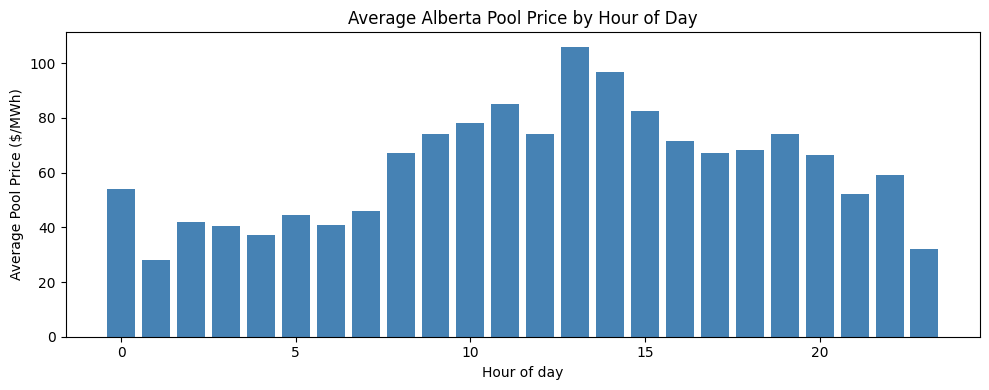

In [9]:
# Average price by hour of day — shows daily demand/price pattern
df["hour"] = df["time_local"].dt.hour
hourly_avg = df.groupby("hour")["pool_price"].mean()

plt.figure(figsize=(10, 4))
plt.bar(hourly_avg.index, hourly_avg.values, color="steelblue")
plt.xlabel("Hour of day")
plt.ylabel("Average Pool Price ($/MWh)")
plt.title("Average Alberta Pool Price by Hour of Day")
plt.tight_layout()
plt.show()


## 9. Export for SQL and Power BI

Two outputs:
- **CSV** — the simplest way to load this into Power BI (`Get Data > Text/CSV`)
- **SQLite database** — lets you write and run real SQL queries against the same data
  (see `aeso_sql_setup.sql` for ready-made queries), and can also be connected to Power BI
  via an ODBC driver if you want to practice that route instead.

Re-running Section 5 onward and then this cell is how you "refresh" the dashboard with new data.


In [10]:
# CSV export
csv_path = "aeso_electricity_data.csv"
df.to_csv(csv_path, index=False)
print(f"Saved {csv_path} ({len(df)} rows)")

# SQLite export
db_path = "aeso_electricity_data.db"
conn = sqlite3.connect(db_path)
df.to_sql("electricity_prices", conn, if_exists="replace", index=False)
conn.close()
print(f"Saved {db_path} — table 'electricity_prices'")


Saved aeso_electricity_data.csv (720 rows)
Saved aeso_electricity_data.db — table 'electricity_prices'


## 10. Summary

| Step | What happened |
|---|---|
| Pull | Called the AESO API (or simulated it) for price + demand |
| Clean | Merged, deduplicated, sorted, filled small gaps |
| Analyze | Flagged price-spike hours using a rolling z-score |
| Export | CSV + SQLite, ready for SQL queries and Power BI |

**Next steps to make this genuinely "live":**
1. Set `USE_LIVE_API = True` and add your real AESO key once you've registered
2. Use Windows Task Scheduler (or `cron` on Mac/Linux) to re-run this notebook automatically,
   e.g. every hour — see `AESO_Dashboard_Explainer.pdf`, Section 5, for exact steps
3. Point Power BI at `aeso_electricity_data.csv` with **Scheduled Refresh** turned on

See `aeso_sql_setup.sql` for the table schema and example SQL queries, and
`AESO_Dashboard_Explainer.pdf` for a plain-language walkthrough of the whole pipeline —
useful both for learning it and for explaining it in an interview.
